Example 1


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2410 - loss: 2.0653 - val_accuracy: 0.3489 - val_loss: 1.8160 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3581 - loss: 1.8012 - val_accuracy: 0.3889 - val_loss: 1.7074 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3909 - loss: 1.7074 - val_accuracy: 0.4056 - val_loss: 1.6700 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4105 - loss: 1.6580 - val_accuracy: 0.4049 - val_loss: 1.6594 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4132 - loss: 1.6308 - val_accuracy: 0.4159 - val_loss: 1.6392 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4242 - loss: 1.6186 - val_accuracy: 0.4141 - val_loss: 1.6483 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4360 - loss: 1.

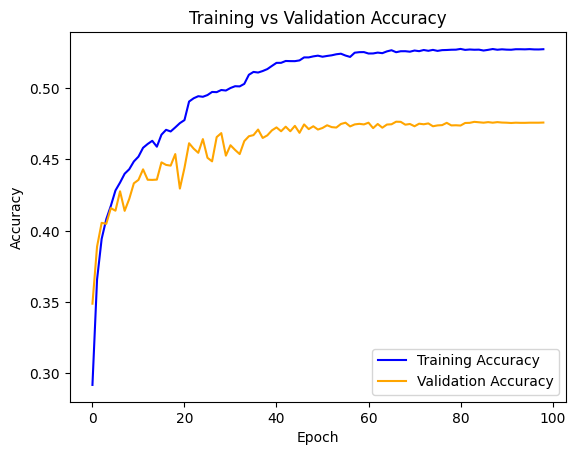

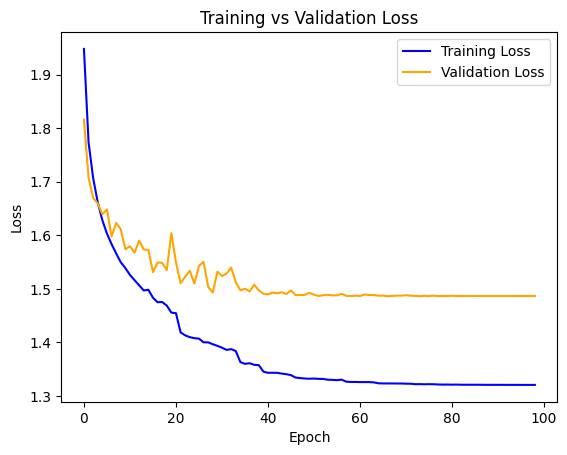

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

# Split training data into train + validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)

# Number of classes
K = len(set(y_train_full))

# Build model
i = Input(shape=x_train.shape[1:])
x = Flatten()(i)
x = Dense(64, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        patience=25,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    ModelCheckpoint(
        'best_model1.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train model
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time
print(f"\n✅ Total training time: {training_time:.2f} seconds")

# Evaluate final model on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Example 2


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.1776 - loss: 2.1877 - val_accuracy: 0.2812 - val_loss: 1.9489 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2563 - loss: 1.9828 - val_accuracy: 0.2961 - val_loss: 1.8979 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2826 - loss: 1.9316 - val_accuracy: 0.3108 - val_loss: 1.8638 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2978 - loss: 1.9091 - val_accuracy: 0.3116 - val_loss: 1.8618 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2991 - loss: 1.8944 - val_accuracy: 0.3092 - val_loss: 1.8597 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3084 - loss: 1.8768 - val_accuracy: 0.3213 - val_loss: 1.8345 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3074 - loss: 1.

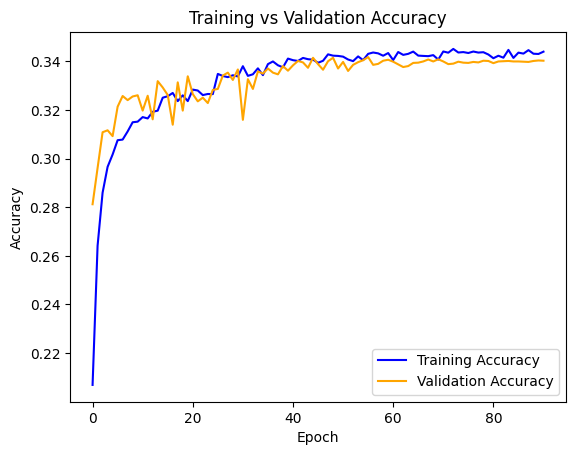

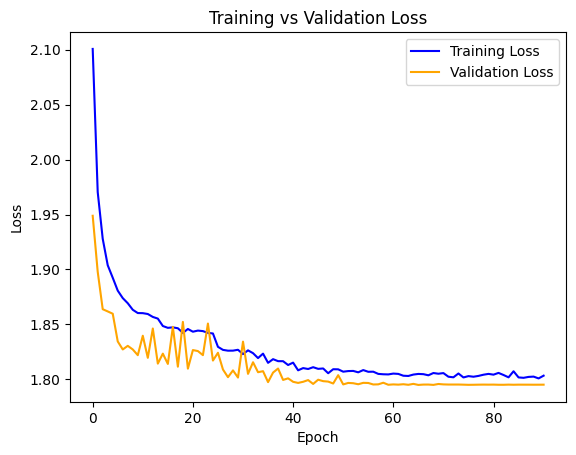

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization , Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)



# Number of classes
K = len(set(y_train_full))

i = Input(shape=x_train.shape[1:])
x = Flatten()(i)
x = Dense(32, activation='relu')(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks: EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        patience=25,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    ModelCheckpoint(
        'best_model2.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

# Train model (using validation set)
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Total training time: {training_time:.2f} seconds")

# Evaluate final model on test set (ONLY once)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Example 3

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3071 - loss: 1.9157 - val_accuracy: 0.5437 - val_loss: 1.2625 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5911 - loss: 1.1344 - val_accuracy: 0.5701 - val_loss: 1.2287 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6756 - loss: 0.9088 - val_accuracy: 0.6373 - val_loss: 1.0447 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7147 - loss: 0.8070 - val_accuracy: 0.6522 - val_loss: 1.0180 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7451 - loss: 0.7118 - val_accuracy: 0.6551 - val_loss: 1.0406 - learning_rate: 0.0010
Epoch 6/100
616/625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7765 - loss: 0.6335
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7763 - loss: 0.63

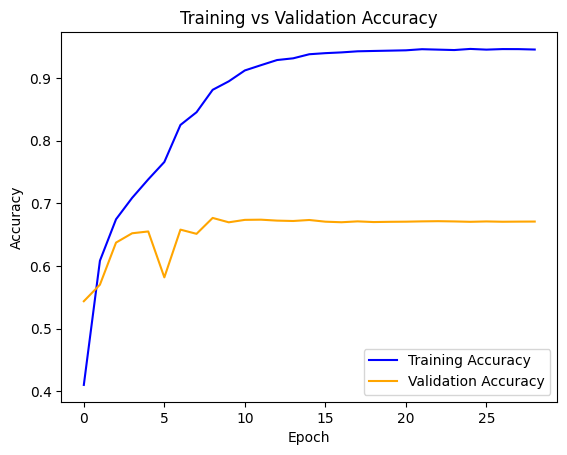

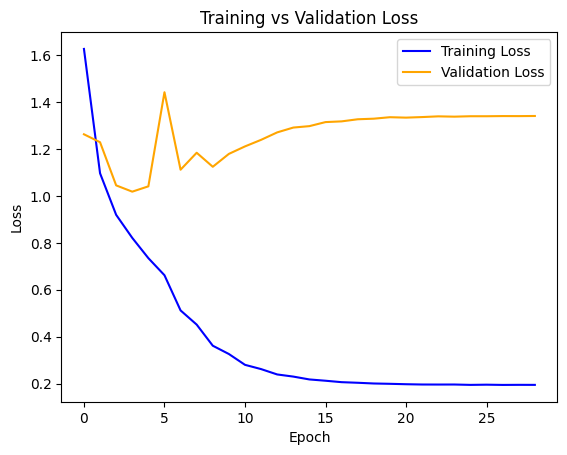

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)



# Number of classes
K = len(set(y_train_full))

i = Input(shape=x_train.shape[1:])

x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Flatten()(x)
x = Dense(32, activation='relu')(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks: EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        patience=25,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    ModelCheckpoint(
        'best_model3.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Train model (using validation set)
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Total training time: {training_time:.2f} seconds")

# Evaluate final model on test set (ONLY once)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Example 4

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4481 - loss: 1.6005 - val_accuracy: 0.5895 - val_loss: 1.1601 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6854 - loss: 0.8857 - val_accuracy: 0.6991 - val_loss: 0.8745 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7564 - loss: 0.6823 - val_accuracy: 0.7216 - val_loss: 0.8006 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8147 - loss: 0.5303 - val_accuracy: 0.7285 - val_loss: 0.8220 - learning_rate: 0.0010
Epoch 5/100
619/625 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8559 - loss: 0.4150
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8557 - loss: 0.4153 - val_accuracy: 0.7255 - val_loss: 0.8732 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9131 - loss: 0

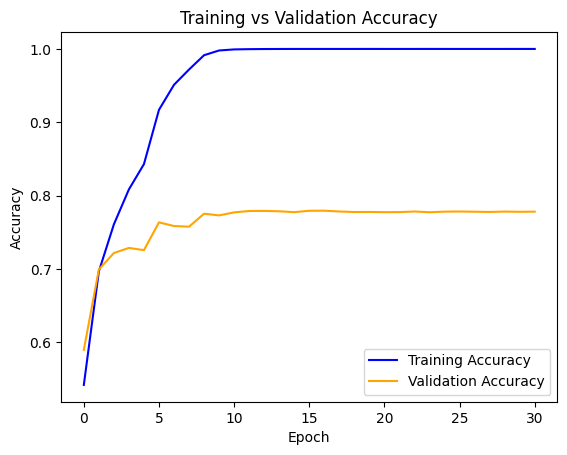

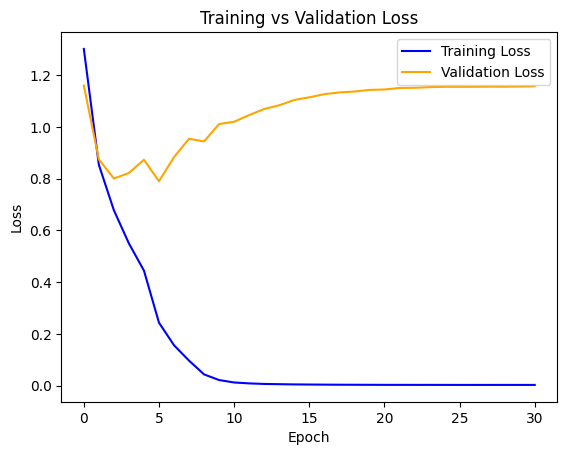

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)



# Number of classes
K = len(set(y_train_full))

i = Input(shape=x_train.shape[1:])

x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)

x = Dense(128, activation='relu')(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks: EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        patience=25,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    ModelCheckpoint(
        'best_model4.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Train model (using validation set)
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Total training time: {training_time:.2f} seconds")

# Evaluate final model on test set (ONLY once)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Example 5

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4520 - loss: 1.6352 - val_accuracy: 0.6392 - val_loss: 1.0144 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7010 - loss: 0.8430 - val_accuracy: 0.6199 - val_loss: 1.2212 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7821 - loss: 0.6287 - val_accuracy: 0.7551 - val_loss: 0.7088 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8248 - loss: 0.4937 - val_accuracy: 0.7705 - val_loss: 0.6767 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8646 - loss: 0.3783 - val_accuracy: 0.7509 - val_loss: 0.7615 - learning_rate: 0.0010
Epoch 6/100
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9043 - loss: 0.2795
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9042 - loss

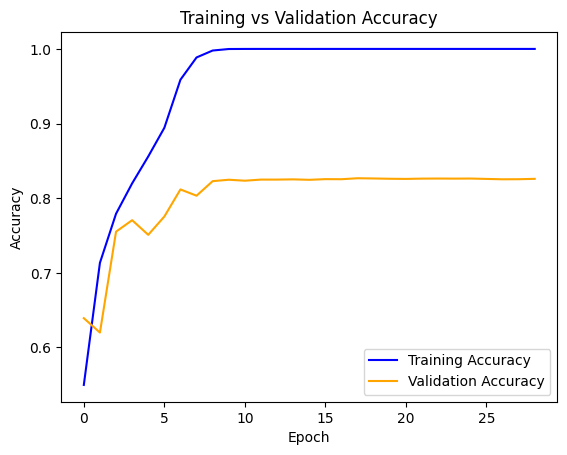

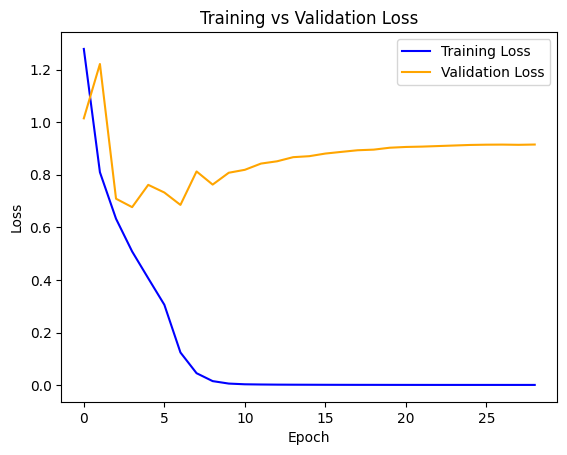

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)



# Number of classes
K = len(set(y_train_full))

i = Input(shape=x_train.shape[1:])

x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)

x = Dense(256, activation='relu')(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks: EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        patience=25,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    ModelCheckpoint(
        'best_model5.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Train model (using validation set)
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Total training time: {training_time:.2f} seconds")

# Evaluate final model on test set (ONLY once)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Example 6




Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.2425 - loss: 2.2710 - val_accuracy: 0.4610 - val_loss: 1.4588 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3945 - loss: 1.6173 - val_accuracy: 0.5702 - val_loss: 1.2177 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5044 - loss: 1.3502 - val_accuracy: 0.6307 - val_loss: 1.0338 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5853 - loss: 1.1694 - val_accuracy: 0.6793 - val_loss: 0.9319 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6339 - loss: 1.0448 - val_accuracy: 0.6999 - val_loss: 0.8745 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6794 - loss: 0.9363 - val_accuracy: 0.7168 - val_loss: 0.8149 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7116 - 

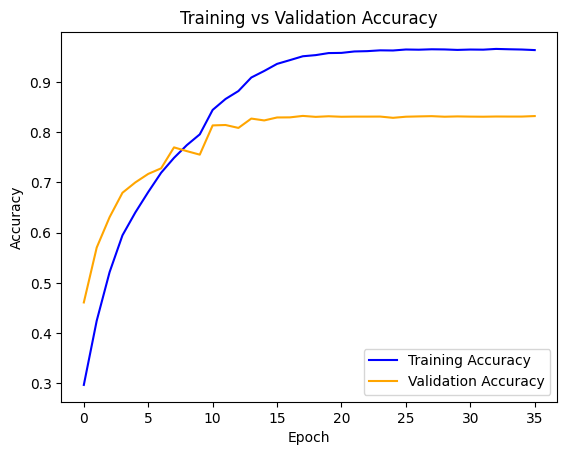

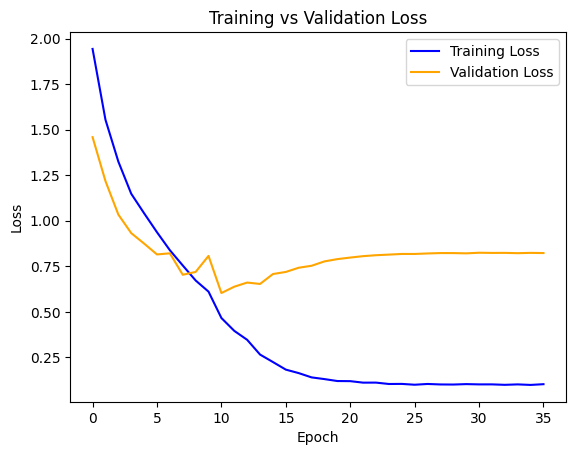

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2

# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)



# Number of classes
K = len(set(y_train_full))

i = Input(shape=x_train.shape[1:])

x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.75)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks: EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        patience=25,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    ModelCheckpoint(
        'best_model6.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Train model (using validation set)
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Total training time: {training_time:.2f} seconds")

# Evaluate final model on test set (ONLY once)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Example 7

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.1391 - loss: 2.8573 - val_accuracy: 0.2381 - val_loss: 2.3025 - learning_rate: 0.0010
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2393 - loss: 2.0607 - val_accuracy: 0.3348 - val_loss: 1.7805 - learning_rate: 0.0010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2865 - loss: 1.9254 - val_accuracy: 0.4232 - val_loss: 1.6260 - learning_rate: 0.0010
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3361 - loss: 1.8134 - val_accuracy: 0.4514 - val_loss: 1.5518 - learning_rate: 0.0010
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3919 - loss: 1.7153 - val_accuracy: 0.5421 - val_loss: 1.4032 - learning_rate: 0.0010
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4632 - loss: 1.5768 - val_accuracy: 0.5924 - val_loss: 1.2610 - learning_rate: 0.0010
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5206 -

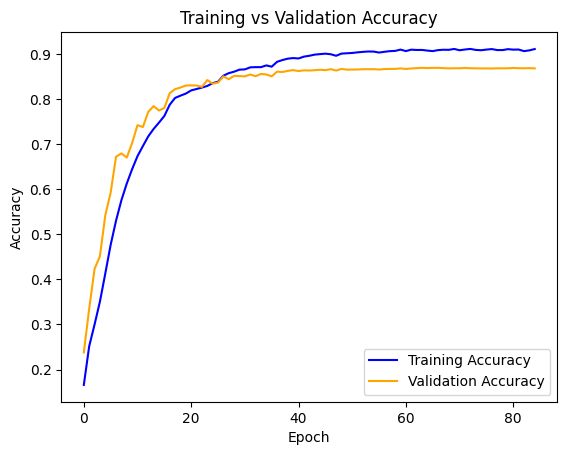

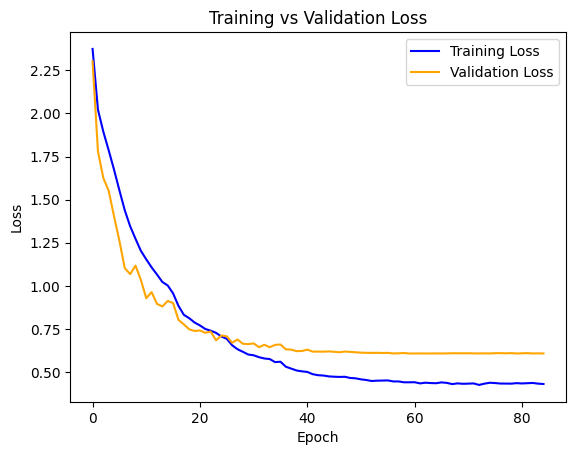

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2

# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)



# Number of classes
K = len(set(y_train_full))

i = Input(shape=x_train.shape[1:])

x = Conv2D(32, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.3)(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.5)(x)
x = Flatten()(x)

x = Dense(256, activation='relu' , kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.75)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks: EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau
callbacks = [
    EarlyStopping(
        patience=25,
        restore_best_weights=True,
        monitor='val_loss'
    ),
    ModelCheckpoint(
        'best_model7.keras',
        save_best_only=True,
        monitor='val_loss'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Train model (using validation set)
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Total training time: {training_time:.2f} seconds")


# Evaluate final model on test set (ONLY once)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Example 8

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.1657 - loss: 3.4921 - val_accuracy: 0.3349 - val_loss: 2.1359
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2747 - loss: 2.2828 - val_accuracy: 0.4346 - val_loss: 1.9010
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3359 - loss: 2.1102 - val_accuracy: 0.4773 - val_loss: 1.7279
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3833 - loss: 1.9638 - val_accuracy: 0.5049 - val_loss: 1.6565
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4169 - loss: 1.8826 - val_accuracy: 0.5323 - val_loss: 1.5766
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4522 - loss: 1.7810 - val_accuracy: 0.5470 - val_loss: 1.5237
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4737 - loss: 1.7190 - val_accuracy: 0.5737 - val_loss: 1.4691
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.4962 - loss: 1.6498 - v

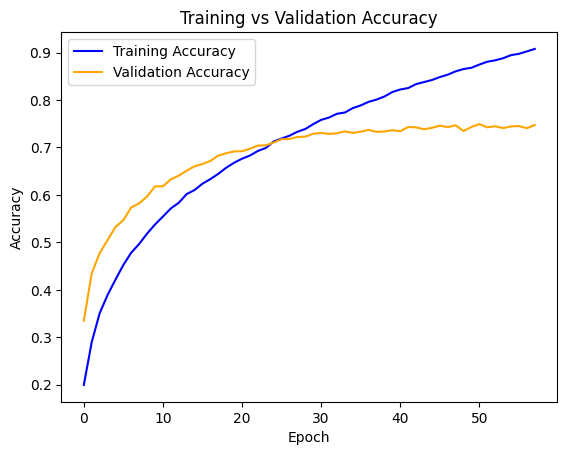

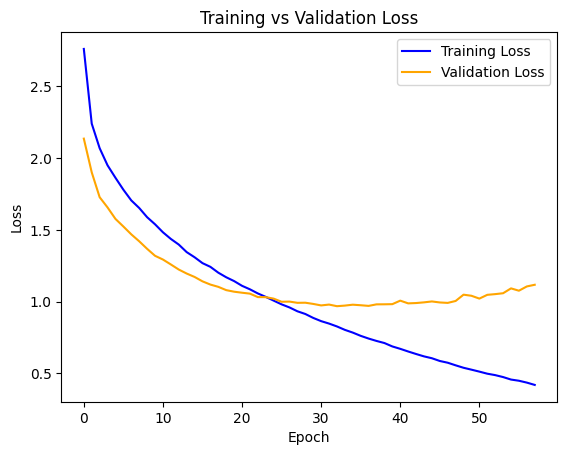

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)



# Number of classes
K = len(set(y_train_full))

i = Input(shape=x_train.shape[1:])

x = Conv2D(32, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)

x = Dense(256, activation='relu' , kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.75)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)


# Compile model
model.compile(optimizer=Adam(learning_rate=5e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# Add callbacks for early stopping and best model saving
callbacks = [
    EarlyStopping(patience=25, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('best_model8.keras', save_best_only=True, monitor='val_loss')
]


# Train model (using validation set)
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=64,
    epochs=100,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Total training time: {training_time:.2f} seconds")


# Evaluate final model on test set (ONLY once)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


Example 9

Epoch 1/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.1175 - loss: 5.7035 - val_accuracy: 0.1403 - val_loss: 3.4710
Epoch 2/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1695 - loss: 3.4331 - val_accuracy: 0.2578 - val_loss: 2.8458
Epoch 3/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1939 - loss: 3.0885 - val_accuracy: 0.3000 - val_loss: 2.7917
Epoch 4/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2170 - loss: 2.9803 - val_accuracy: 0.3217 - val_loss: 2.7350
Epoch 5/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2400 - loss: 2.9084 - val_accuracy: 0.3479 - val_loss: 2.6779
Epoch 6/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2621 - loss: 2.8491 - val_accuracy: 0.3677 - val_loss: 2.6201
Epoch 7/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2759 - loss: 2.8077 - val_accuracy: 0.3818 - val_loss: 2.5681
Epoch 8/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.2970 - loss: 2.7560 -

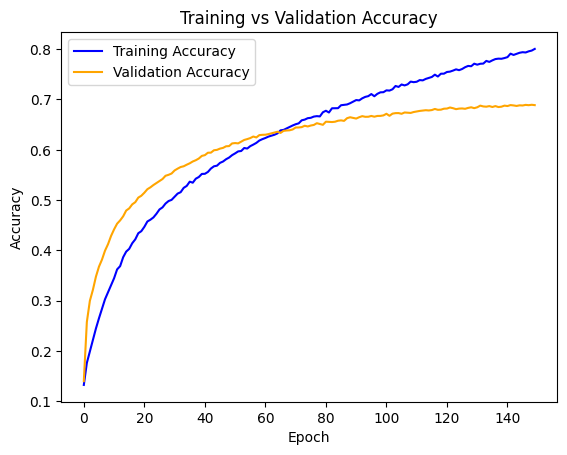

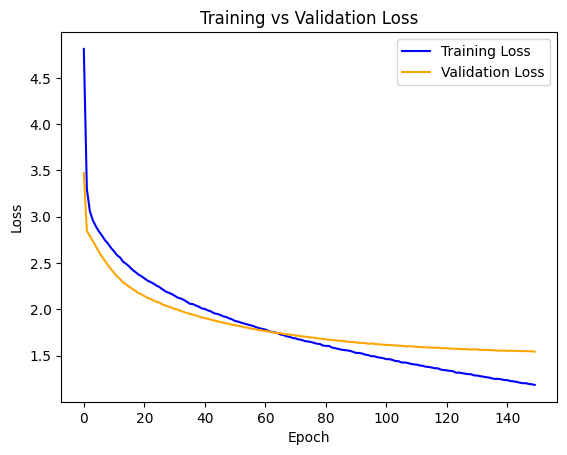

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam


# Load and prepare CIFAR-10 data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train_full, x_test = x_train_full / 255.0, x_test / 255.0

# Flatten label arrays
y_train_full, y_test = y_train_full.flatten(), y_test.flatten()

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42
)



# Number of classes
K = len(set(y_train_full))

i = Input(shape=x_train.shape[1:])

x = Conv2D(32, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(0.001))(i)
x = BatchNormalization()(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same' , kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)
x = Flatten()(x)

x = Dense(256, activation='relu' , kernel_regularizer=l2(0.001))(x)
x = Dropout(0.75)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)


# Compile model
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


# Add callbacks for early stopping and best model saving
callbacks = [
    EarlyStopping(patience=25, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('best_model9.keras', save_best_only=True, monitor='val_loss')
]


# Train model (using validation set)
start_time = time.time()

r = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=128,
    epochs=150,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n✅ Total training time: {training_time:.2f} seconds")


# Evaluate final model on test set (ONLY once)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

# Plot training and validation accuracies
plt.plot(r.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation losses
plt.plot(r.history['loss'], label='Training Loss', color='blue')
plt.plot(r.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()




1st Classify Example


 Model loaded successfully!


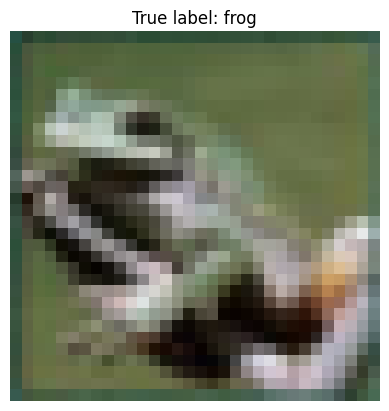

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
 Predicted class: frog
 True class: frog


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import cifar10


# Load the trained model
model = load_model('best_model2.keras')
print(" Model loaded successfully!")


# Load CIFAR-10 test data
(_, _), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_test = x_test / 255.0
y_test = y_test.flatten()

# Class names for CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


# Choose one image to predict
index = 6700
img = x_test[index]
true_label = y_test[index]

# Display the image
plt.imshow(img)
plt.title(f"True label: {class_names[true_label]}")
plt.axis('off')
plt.show()


# Prepare image for prediction
img_expanded = np.expand_dims(img, axis=0)


# Make prediction
pred_probs = model.predict(img_expanded)
pred_class = np.argmax(pred_probs, axis=1)[0]


# Show results
print(" Predicted class:", class_names[pred_class])
print(" True class:", class_names[true_label])


2nd Classify Example

 Model loaded successfully!


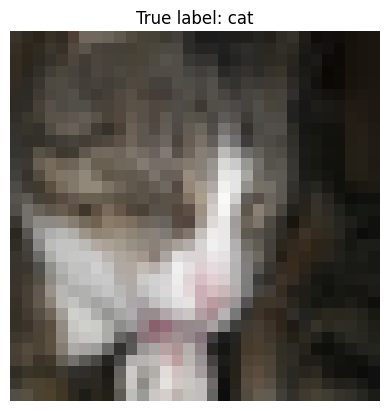

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
 Predicted class: dog
 True class: cat


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import cifar10


# Load the trained model
model = load_model('best_model2.keras')
print(" Model loaded successfully!")


# Load CIFAR-10 test data
(_, _), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_test = x_test / 255.0
y_test = y_test.flatten()

# Class names for CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


# Choose one image to predict
index = 6769
img = x_test[index]
true_label = y_test[index]

# Display the image
plt.imshow(img)
plt.title(f"True label: {class_names[true_label]}")
plt.axis('off')
plt.show()


# Prepare image for prediction
img_expanded = np.expand_dims(img, axis=0)


# Make prediction
pred_probs = model.predict(img_expanded)
pred_class = np.argmax(pred_probs, axis=1)[0]


# Show results
print(" Predicted class:", class_names[pred_class])
print(" True class:", class_names[true_label])


3rd Classify Example

 Model loaded successfully!


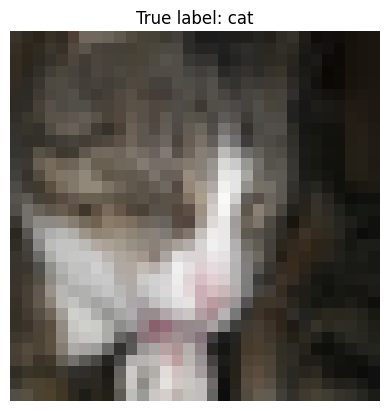

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
 Predicted class: cat
 True class: cat


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import cifar10


# Load the trained model
model = load_model('best_model7.keras')
print(" Model loaded successfully!")


# Load CIFAR-10 test data
(_, _), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_test = x_test / 255.0
y_test = y_test.flatten()

# Class names for CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]


# Choose one image to predict
index = 6769
img = x_test[index]
true_label = y_test[index]

# Display the image
plt.imshow(img)
plt.title(f"True label: {class_names[true_label]}")
plt.axis('off')
plt.show()


# Prepare image for prediction
img_expanded = np.expand_dims(img, axis=0)


# Make prediction
pred_probs = model.predict(img_expanded)
pred_class = np.argmax(pred_probs, axis=1)[0]


# Show results
print(" Predicted class:", class_names[pred_class])
print(" True class:", class_names[true_label])


KNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


#Flatten the images so that each sample is a 2D vector of features.

x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

#Predict and evaluate
knn1 = KNeighborsClassifier(n_neighbors=1)
start_time1 = time.time()
knn1.fit(x_train_flat, y_train_flat)
y_pred1 = knn1.predict(x_test_flat)
end_time1 = time.time()

knn2 = KNeighborsClassifier(n_neighbors=3)
start_time2 = time.time()
knn2.fit(x_train_flat, y_train_flat)
y_pred2 = knn2.predict(x_test_flat)
end_time2 = time.time()

print(f"Test Accuracy (Κ=1): {accuracy_score(y_test, y_pred1)*100:.2f}%")
print(f"Κ={1} Training time: {end_time1 - start_time1:.2f} seconds\n")
print(f"Test Accuracy (Κ=3): {accuracy_score(y_test, y_pred2)*100:.2f}%")
print(f"K={3} Training time: {end_time2 - start_time2:.2f} seconds\n")

Test Accuracy (Κ=1): 35.39%
Κ=1 Training time: 91.60 seconds

Test Accuracy (Κ=3): 33.03%
K=3 Training time: 88.58 seconds



NC

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import time
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import accuracy_score

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()


#Flatten the images

x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))
y_train_flat = y_train.ravel()
y_test_flat = y_test.ravel()

#Predict and evaluate
nc = NearestCentroid()
start_time = time.time()
nc.fit(x_train_flat, y_train_flat)
y_pred = nc.predict(x_test_flat)
end_time = time.time()

print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Training time: {end_time - start_time:.2f} seconds\n")

Test Accuracy: 27.74%
Training time: 1.55 seconds

